## Лабораторная работа № 5

Вам представлены следующие данные:

Таблица movies содержит информацию из реестра прокатных удостоверений. У одного фильма может быть несколько прокатных удостоверений. 
- tle — название фильма;
- puNumber — номер прокатного удостоверения;
- show_start_date — дата премьеры фильма;
- type — тип фильма;
- film_studio — студия-производитель;
- production_country — страна-производитель;
- director — режиссёр;
- producer — продюсер;
- age_restriction — возрастная категория;
- refundable_support — объём возвратных средств государственной поддержки;
- nonrefundable_support — объём невозвратных средств государственной поддержки;
- financing_source — источник государственного финансирования;
- budget — общий бюджет фильма;
- ratings — рейтинг фильма на КиноПоиске;
- genres — жанр фильма.

Таблица shows содержит сведения о показах фильмов в российских кинотеатрах.
- puNumber — номер прокатного удостоверения;
- box_office — сборы в рублях.

Ваша задача предсказать рейтинг фильма на КиноПоиске
1) Анализ и предобработка
- Проанализировать данные (EDA).
- Предобработать данные.
- Скалировать/нормализовать данные.
2) Построение простой модели нейронной сети — baseline
- Создайте класс для задания архитектуры нейронной сети.
- Самостоятельно выберите количество скрытых слоев, количество нейронов на них, функции активации на скрытых и выходном слоях. Попробуйте и сравните несколько подобных комбинаций.
- Создайте функцию для обучения нейронной сети.
- Проведите обучение модели.
- Постройте гистограмму «Факт — Прогноз», чтобы наглядно увидеть, как сильно модель ошибается.
3) Улучшение сети
- Создайте решение с перебором параметров нейросети и обучения. Список параметров для перебора должен включать как минимум выбор функции активации, наличие/значение dropout, наличие нормализации и размер батча. Архитектуру нейронной сети, количество слоев и нейронов оставьте как в Baseline, чтобы сравнить результат.
- Проведите обучение. Постройте графики зависимости значений подбираемых параметров и значения метрики RMSE.
- Выберите лучшую модель и постройте гистограмму «Факт — прогноз». 
- Сделайте вывод.

#### 1) Анализ и предобработка:

In [362]:
import pandas as pd 

data = pd.read_csv('movies.csv')
data1 = pd.read_csv('shows.csv')

# Соединим данные в один dataFrame
data['puNumber'] = data['puNumber'].astype(str)
data1['puNumber'] = data1['puNumber'].astype(str)
data = data.merge(data1[['puNumber', 'box_office']], on='puNumber', how='left')

print(data.info())
data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7486 entries, 0 to 7485
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  7486 non-null   object 
 1   puNumber               7486 non-null   object 
 2   show_start_date        7486 non-null   object 
 3   type                   7486 non-null   object 
 4   film_studio            7468 non-null   object 
 5   production_country     7484 non-null   object 
 6   director               7477 non-null   object 
 7   producer               6918 non-null   object 
 8   age_restriction        7486 non-null   object 
 9   refundable_support     332 non-null    float64
 10  nonrefundable_support  332 non-null    float64
 11  budget                 332 non-null    float64
 12  financing_source       332 non-null    object 
 13  ratings                6519 non-null   object 
 14  genres                 6510 non-null   object 
 15  box_

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
0,Открытый простор,221048915,2015-11-27T12:00:00.000Z,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама",NaN
1,Особо важное задание,111013716,2016-09-13T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный",NaN
2,Особо опасен,221038416,2016-10-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
3,Особо опасен,221026916,2016-06-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
4,Особо опасен,221030815,2015-07-29T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7481,Сад художника: Американский импрессионизм,126008019,2019-12-23T12:00:00.000Z,Прочие,Севен Артс Продакшнз,Великобритания,Фил Грабски,Фил Грабски,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7482,Звериная ярость,121037819,2019-12-24T12:00:00.000Z,Художественный,"Дэниел Гродник Продакшнз, Вандерфилм Медиа Кор...",США,Ник Пауэлл,"Джефф Боулер, Дэниэл Гродник, Луильо Руис, Брэ...",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,5.4,"боевик,триллер",NaN
7483,Щенячий патруль: Скорей спешим на помощь!,124010819,2019-12-28T12:00:00.000Z,Художественный,"Никелодеон Анимейшн Студиос, Спин Мастер",США - Канада,Чарльз Е.Бастьен,Дженнифер Додж,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7484,"Машины песенки. Серия ""Испанские мотивы""",124010619,2019-12-30T12:00:00.000Z,Анимационный,"Анимаккорд Лтд., ООО Студия ""АНИМАККОРД""","Республика Кипр, Россия",А.Беляев,Д.Ловейко,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Удалим признаки 'title' и 'puNumber', так как они не влияют на наш таргет - рейтинг 

In [363]:
data = data.drop(['title', 'puNumber'], axis=1)

show_start_date -> datetime -> year, month

От даты оставим только год и месяц - сделаем их отдельными признаками

In [364]:
data['show_start_date'] = pd.to_datetime(data['show_start_date'], format='%Y-%m-%dT%H:%M:%S.%fZ')
data['year'] = data['show_start_date'].dt.year
data['month'] = data['show_start_date'].dt.month
data = data.drop('show_start_date', axis=1)

ratings

Некоторые значения выражены в процентах. Приведем все к одному виду (дробному)

Заполним пропуски медианой

In [365]:
data['ratings'] = data['ratings'].str.replace('%', '')
data['ratings'] = data['ratings'].astype(float)

data.loc[data['ratings'] > 10, 'ratings'] = data['ratings'] / 10

data['ratings'] = data['ratings'].fillna(data['ratings'].median())

type -> one-hot encoding 

In [366]:
from sklearn.preprocessing import OneHotEncoder

data['type'] = data['type'].str.replace(' ', '')
print(data['type'].unique())

encoder = OneHotEncoder(sparse_output=False)
type_encoded = encoder.fit_transform(data[['type']])
dummy_df = pd.DataFrame(
    type_encoded,
    columns=encoder.get_feature_names_out(['type']), 
    index=data.index  
)
data = pd.concat([data, dummy_df], axis=1)
data = data.drop('type', axis=1)

['Художественный' 'Анимационный' 'Прочие' 'Документальный'
 'Научно-популярный' 'Музыкально-развлекательный']


film_studio, director и producer

Удалим признаки film_studio, director и producer, поскольку это категориальные данные с большим количеством уникальных значений, и нет уверенности в том, что конкретные студии/режиссеры/продюсеры влияют на рейтинг фильма

In [367]:
data = data.drop(['film_studio', 'director', 'producer'], axis=1)

production_country -> one-hot encoding 

Сначала приведем все записи к одному виду - страны должны разделяться только запятыми. Затем оставим во всех записях только первую страну из списка. Найдем топ 5 самых популярных стран-производителей, остальные заменим на 'Другое'. Пропуски заменим на 'Россия' (было всего 2 пропуска, посмотрели, что это за фильмы, и выяснили, что производителям является Россия). 

In [368]:
data['production_country'] = data['production_country'].str.replace('-', ',')
data['production_country'] = data['production_country'].str.replace(' ', '')
data['production_country'] = data['production_country'].str.split(',').str[0].str.strip()

data['production_country'] = data['production_country'].replace(['СЩА', 'CША', 'Сша'], 'США')
data['production_country'] = data['production_country'].replace('РеспубликаКорея', 'Корея')
data['production_country'] = data['production_country'].replace('РеспубликаКазахстан', 'Казахстан')
data['production_country'] = data['production_country'].replace('КНР', 'Китай')
data['production_country'] = data['production_country'].replace('Норвения', 'Норвегия')

top_5 = data['production_country'].value_counts().head(5)
print(top_5)
data['production_country'] = data['production_country'].fillna('Россия')
data.loc[~data['production_country'].isin(top_5.index), 'production_country'] = 'Другое'

encoder = OneHotEncoder(sparse_output=False)
type_encoded = encoder.fit_transform(data[['production_country']])
dummy_df = pd.DataFrame(
    type_encoded,
    columns=encoder.get_feature_names_out(['production_country']), 
    index=data.index  
)
data = pd.concat([data, dummy_df], axis=1)
data = data.drop('production_country', axis=1)

production_country
США               2756
Россия            1912
Франция            535
Великобритания     443
СССР               407
Name: count, dtype: int64


age_restriction -> one-hot encoding

Сначала приведем записи к одному виду - 'x+', затем закодируем

In [369]:
data['age_restriction'] = data['age_restriction'].str.split('»').str[0].str.strip()
data['age_restriction'] = data['age_restriction'].str.replace('«', '')

encoder = OneHotEncoder(sparse_output=False)
type_encoded = encoder.fit_transform(data[['age_restriction']])
dummy_df = pd.DataFrame(
    type_encoded,
    columns=encoder.get_feature_names_out(['age_restriction']), 
    index=data.index  
)
data = pd.concat([data, dummy_df], axis=1)
data = data.drop('age_restriction', axis=1)

budget, refundable_support и nonrefundable_support

Как можно видеть по тепловой карте, наш таргет ratings очень слабо коррелирует с признаками budget, refundable_support и nonrefundable_support, поэтому можно без зазрения совести удалить их из датасета 

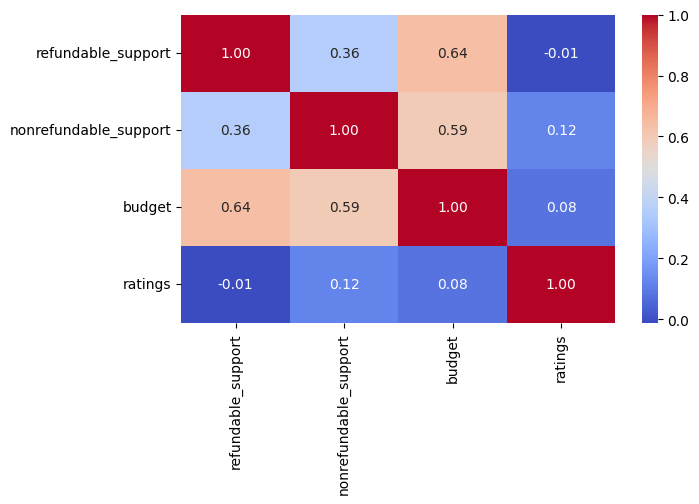

In [370]:
import seaborn as sns
import matplotlib.pyplot as plt

df = data.copy()
df = df.dropna(subset=['budget', 'refundable_support', 'nonrefundable_support'])

corr_matrix = df.loc[:, df.columns.isin(['ratings', 'budget', 'refundable_support', 'nonrefundable_support'])].corr()
plt.figure(figsize=(7, 4))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

data = data.drop(['budget', 'refundable_support', 'nonrefundable_support'], axis=1)

financing_source  

Проанализируем распределение таргета внутри категорий financing_source. Как можно видеть, распределения таргета очень похожи между категориями financing_source, так что можно сделать вывод, что ratings не зависит от financing_source, и поэтому этот признак можно удалить

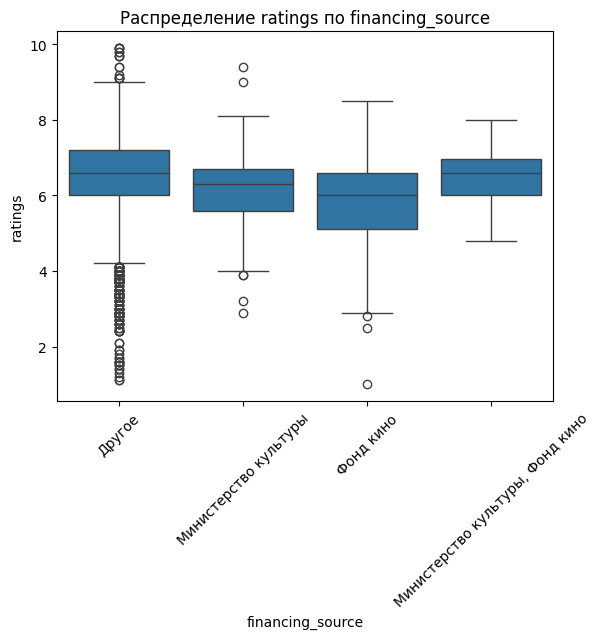

In [371]:
df = data.copy()
df['financing_source'] = df['financing_source'].fillna('Другое')

sns.boxplot(x='financing_source', y='ratings', data=df)
plt.title('Распределение ratings по financing_source')
plt.xticks(rotation=45)
plt.show()

data = data.drop('financing_source', axis=1)

genres -> multi-hot encoding

Заменим пропуски на 'Другие', найдем 5 самых популярных жанров, остальные заменим на 'Другие' и закодируем с помощью multi-hot encoding. 

In [372]:
from sklearn.preprocessing import MultiLabelBinarizer
from collections import Counter

data['genres'] = data['genres'].fillna('Другие') 
data['genres_split'] = data['genres'].str.split(',')

all_genres = [genre for sublist in data['genres_split'] for genre in sublist]
genre_counts = Counter(all_genres)

top_genres = [genre for genre, count in genre_counts.most_common(5)]  

data['genres_grouped'] = data['genres_split'].apply(
    lambda x: [g if g in top_genres else 'Другие' for g in x]
)

print(top_genres)

mlb = MultiLabelBinarizer()
genres_encoded = pd.DataFrame(
    mlb.fit_transform(data['genres_grouped']),
    columns=mlb.classes_,
    index=data.index
)

data = pd.concat([data, genres_encoded], axis=1)
data = data.drop(['genres', 'genres_split', 'genres_grouped'], axis=1)

['драма', 'комедия', 'триллер', 'мелодрама', 'боевик']


box_office

Как можно видеть, признак box_office слабо коррелирует с таргетом, поэтому мы просто удалим его 

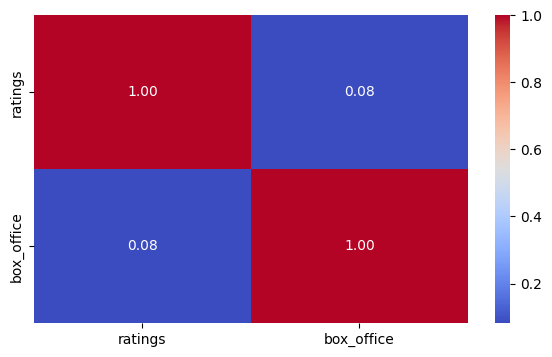

In [373]:
df = data.copy()
df = df.dropna(subset=['box_office'])

corr_matrix = df.loc[:, df.columns.isin(['ratings', 'box_office'])].corr()
plt.figure(figsize=(7, 4))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

data = data.drop('box_office', axis=1)

In [381]:
data = data.drop_duplicates()

print(data.info())
data

<class 'pandas.core.frame.DataFrame'>
Index: 6979 entries, 0 to 7485
Data columns (total 26 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   ratings                            6979 non-null   float64
 1   year                               6979 non-null   int32  
 2   month                              6979 non-null   int32  
 3   type_Анимационный                  6979 non-null   float64
 4   type_Документальный                6979 non-null   float64
 5   type_Музыкально-развлекательный    6979 non-null   float64
 6   type_Научно-популярный             6979 non-null   float64
 7   type_Прочие                        6979 non-null   float64
 8   type_Художественный                6979 non-null   float64
 9   production_country_Великобритания  6979 non-null   float64
 10  production_country_Другое          6979 non-null   float64
 11  production_country_Россия          6979 non-null   float64
 1

,ratings,year,month,type_Анимационный,type_Документальный,type_Музыкально-развлекательный,type_Научно-популярный,type_Прочие,type_Художественный,production_country_Великобритания,...,age_restriction_12+,age_restriction_16+,age_restriction_18+,age_restriction_6+,Другие,боевик,драма,комедия,мелодрама,триллер
0,7.2,2015,11,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0,1,1,0,1,0
1,6.6,2016,9,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,1,0,1,0,0,0
2,6.8,2016,10,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1,1,0,0,0,1
3,6.8,2016,6,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1,1,0,0,0,1
4,6.8,2015,7,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7478,4.5,2019,12,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1,0,0,1,1,0
7479,6.6,2019,12,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1,0,0,0,0,0
7482,5.4,2019,12,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0,1,0,0,0,1
7483,6.6,2019,12,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1,0,0,0,0,0


##### Гистограммы 

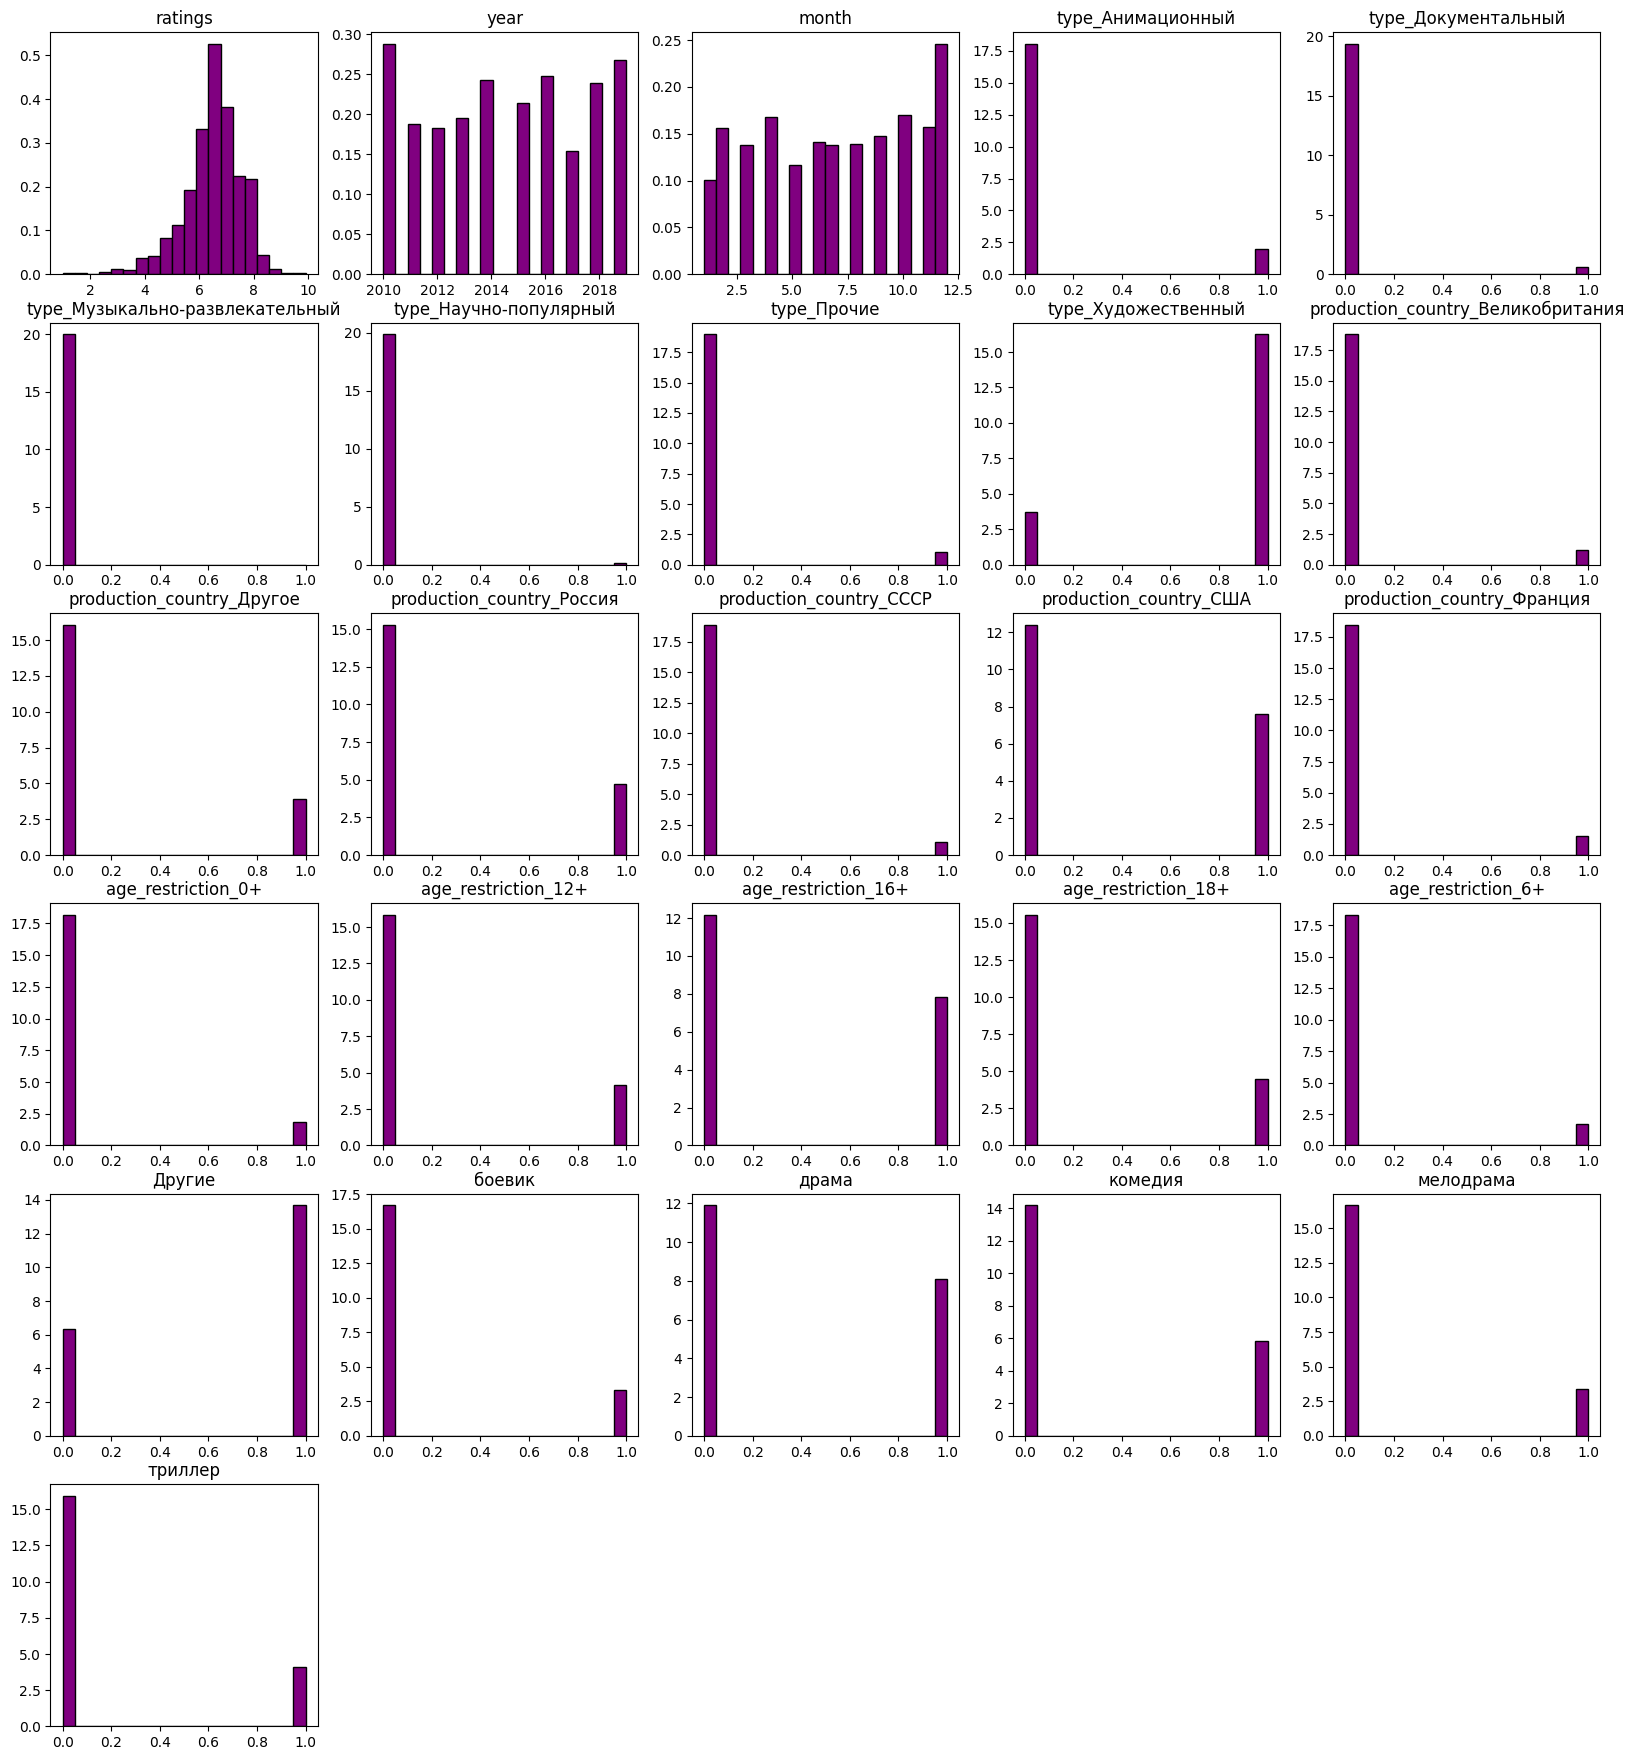

In [402]:
plt.figure(figsize=(20,22))
i = 1
for column in data.columns:
    plt.subplot(6, 5, i)
    plt.hist(data[column], density=True, color = 'purple', edgecolor = 'black', bins=20)
    plt.title(column)
    i += 1
plt.show()

Распределение таргета похоже на нормальное распределение 

Распределение year и month больше всего похоже на равномерное распределение

##### Ящики с усами 

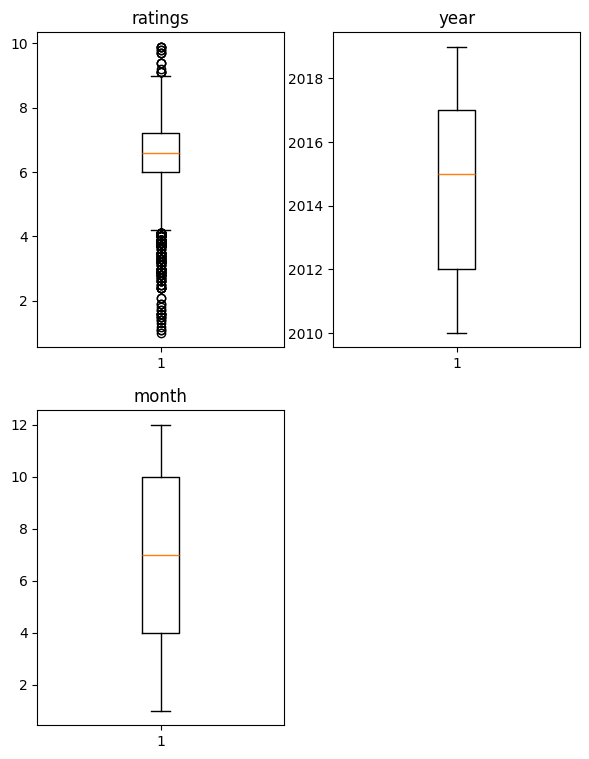

In [401]:
plt.figure(figsize=(7,9))
i = 1
for column in data.columns:
    if column in ['ratings', 'year', 'month']:
        plt.subplot(2, 2, i)
        plt.boxplot(data[column])
        plt.title(column)
        i += 1
plt.show()

Выбросов в признаках year и month нет. 

Выбросы в таргете заменим на граничные значения

Text(0.5, 1.0, 'ratings')

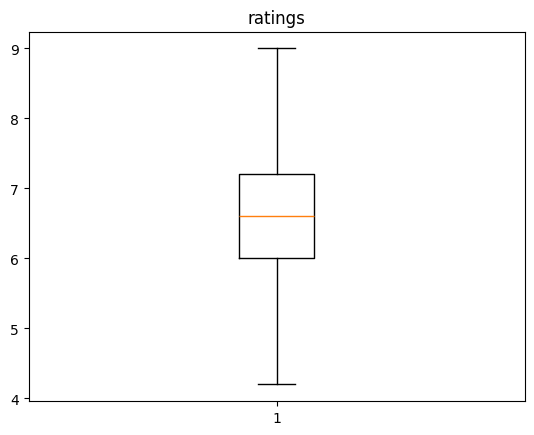

In [408]:
Q1 = data['ratings'].quantile(0.25)
Q3 = data['ratings'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

data.loc[data['ratings'] > upper_bound, 'ratings'] = upper_bound
data.loc[data['ratings'] < lower_bound, 'ratings'] = lower_bound

plt.boxplot(data['ratings'])
plt.title('ratings')

##### Скалируем данные 

In [429]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import ColumnTransformer

X = data.drop('ratings', axis=1) 
y = data['ratings']  

X_train, X_val, y_train, y_val = train_test_split(
    X, 
    y, 
    test_size=0.2
)

scaler = MinMaxScaler()
features_to_scale = ['year', 'month']
X_train[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])
X_val[features_to_scale] = scaler.transform(X_val[features_to_scale])

#### 2) Построение простой модели нейронной сети — baseline:

##### Создадим класс для задания архитектуры нейронной сети

In [405]:
import torch.nn as nn

class RatingPredictor(nn.Module):
    def __init__(self, input_size, hidden_layers=[256, 128, 64], dropout_rate=0.2):
        """
        input_size (int): количество нейронов на входном слое
        hidden_layers (list): список с количеством нейронов в каждом скрытом слое (здесь 3 скрытых слоя)
        dropout_rate (float): вероятность dropout для регуляризации
        """

        super(RatingPredictor, self).__init__()
        
        layers = []
        prev_size = input_size
        
        # Добавляем скрытые слои
        for i, hidden_size in enumerate(hidden_layers):
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.BatchNorm1d(hidden_size)) 
            layers.append(nn.ReLU())  # Функция активации
            layers.append(nn.Dropout(dropout_rate))
            prev_size = hidden_size
        
        # Выходной слой (без функции активации для регрессии)
        layers.append(nn.Linear(prev_size, 1))
        
        # Объединяем все слои в последовательную модель
        self.model = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.model(x)
    

##### Создадим функцию для обучения нейронной сети

In [410]:
import torch
import torch.optim as optim
import numpy as np

def train_model(model, X_train, y_train, X_val, y_val, 
                epochs=400, batch_size=32, learning_rate=0.001):
    """
    - model: экземпляр нейронной сети
    - X_train, y_train: обучающие данные и целевая переменная
    - X_val, y_val: валидационные данные для контроля обучения
    - epochs: количество эпох обучения
    - batch_size: размер батча
    - learning_rate: скорость обучения
    """
    
    # Преобразуем данные в тензоры PyTorch
    X_train_tensor = torch.FloatTensor(X_train.values)
    y_train_tensor = torch.FloatTensor(y_train.values).view(-1, 1)
    X_val_tensor = torch.FloatTensor(X_val.values)
    y_val_tensor = torch.FloatTensor(y_val.values).view(-1, 1)
    
    # Определяем функцию потерь (MSE) и оптимизатор (Adam)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # Для хранения истории обучения
    train_losses = []
    val_losses = []
    
    # Создаем DataLoader для батчей
    train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    # Цикл обучения
    for epoch in range(epochs):
        model.train()  # Переводим модель в режим обучения
        batch_losses = []
        
        # Обучение по батчам
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            
            # Прямой проход
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            # Обратный проход и оптимизация
            loss.backward()
            optimizer.step()
            
            batch_losses.append(loss.item())
        
        # Средний loss по батчам
        train_loss = np.mean(batch_losses)
        train_losses.append(train_loss)
        
        # Валидация
        model.eval()  # Переводим модель в режим оценки
        with torch.no_grad():
            val_outputs = model(X_val_tensor)
            val_loss = criterion(val_outputs, y_val_tensor)
            val_losses.append(val_loss.item())
        
        # Выводим прогресс каждые 10 эпох
        if (epoch+1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss.item():.4f}')
    
    # График обучения
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.show()
    
    return model, train_losses, val_losses

##### Обучим модель

Epoch [10/150], Train Loss: 1.2379, Val Loss: 0.8309
Epoch [20/150], Train Loss: 1.1264, Val Loss: 0.8231
Epoch [30/150], Train Loss: 1.0342, Val Loss: 0.8621
Epoch [40/150], Train Loss: 0.9985, Val Loss: 0.8154
Epoch [50/150], Train Loss: 0.9500, Val Loss: 0.8098
Epoch [60/150], Train Loss: 0.9145, Val Loss: 0.7980
Epoch [70/150], Train Loss: 0.8952, Val Loss: 0.7954
Epoch [80/150], Train Loss: 0.8545, Val Loss: 0.8126
Epoch [90/150], Train Loss: 0.8344, Val Loss: 0.8324
Epoch [100/150], Train Loss: 0.8274, Val Loss: 0.8218
Epoch [110/150], Train Loss: 0.7943, Val Loss: 0.8237
Epoch [120/150], Train Loss: 0.7583, Val Loss: 0.8101
Epoch [130/150], Train Loss: 0.7542, Val Loss: 0.8281
Epoch [140/150], Train Loss: 0.7513, Val Loss: 0.8279
Epoch [150/150], Train Loss: 0.7263, Val Loss: 0.8292


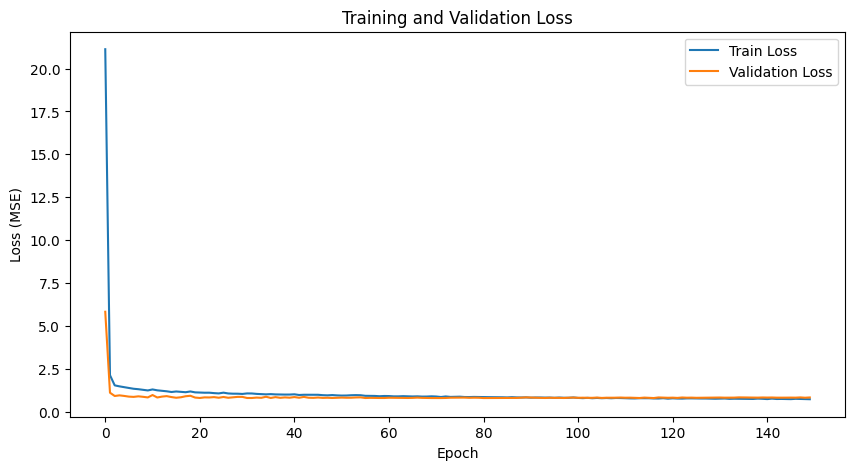

In [437]:
input_size = X_train.shape[1]

model = RatingPredictor(input_size, hidden_layers=[256, 128, 64], dropout_rate=0.2)

trained_model, train_loss, val_loss = train_model(
    model, 
    X_train, y_train, 
    X_val, y_val,
    epochs=150,
    batch_size=32,
    learning_rate=0.001
)

Видно, что модель неплохо обучается примерно на 70 эпохах, дальше происходит переобучение

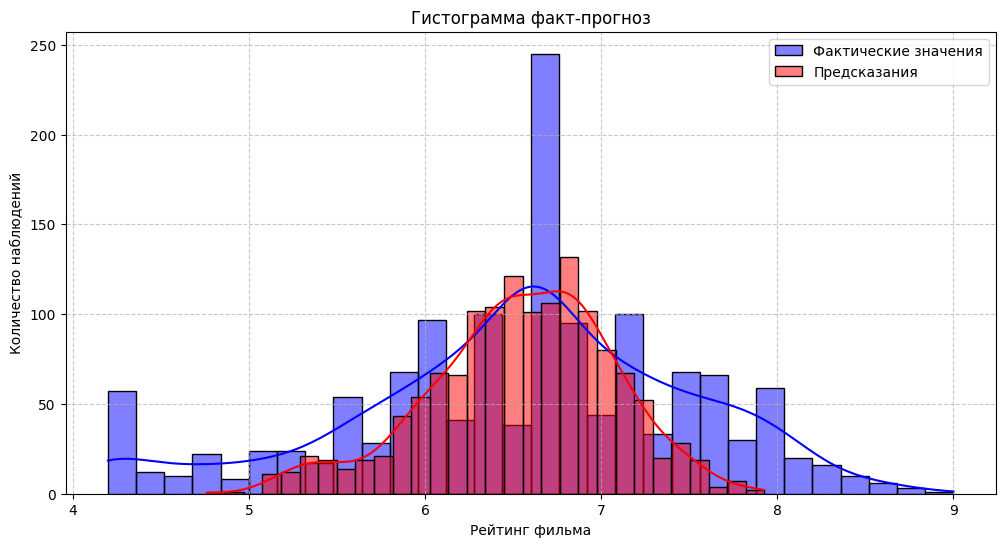

In [439]:
def plot_prediction_histogram(y_true, y_pred, bins=30):
    plt.figure(figsize=(12, 6))
    
    sns.histplot(y_true, bins=bins, color='blue', alpha=0.5, label='Фактические значения', kde=True)
    sns.histplot(y_pred, bins=bins, color='red', alpha=0.5, label='Предсказания', kde=True)
    
    plt.title('Гистограмма факт-прогноз')
    plt.xlabel('Рейтинг фильма')
    plt.ylabel('Количество наблюдений')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

with torch.no_grad():
    X_val_tensor = torch.FloatTensor(X_val.values)
    y_pred = model(X_val_tensor).flatten()

y_true = y_val.values if hasattr(y_val, 'values') else y_val

plot_prediction_histogram(y_true, y_pred)

Видно, что модель чаще занижает оценки ближе к границам распределения и завышает в центре, а также придсказывает оценки в более узком диапазоне, нежели есть на самом деле

#### 3) Улучшение сети:

100%|██████████| 54/54 [09:16<00:00, 10.31s/it]


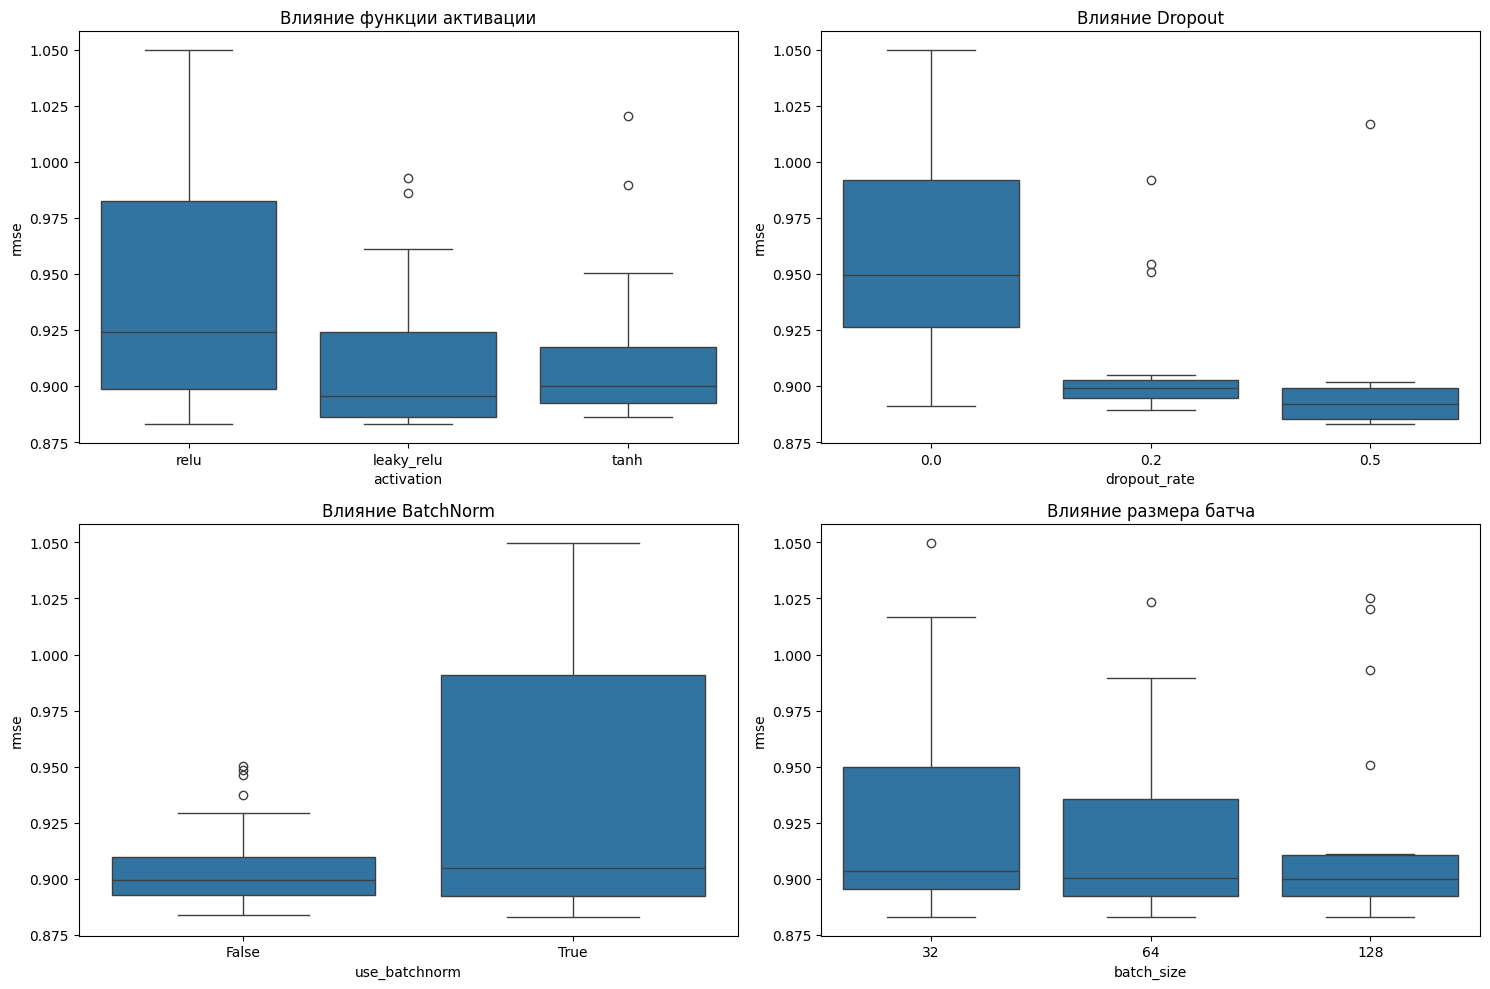

Лучшие параметры: {'activation': 'leaky_relu', 'dropout_rate': 0.5, 'use_batchnorm': True, 'batch_size': 64}
Лучший RMSE: 0.8829


In [441]:
from sklearn.metrics import mean_squared_error
from itertools import product
from tqdm import tqdm

class FilmRatingPredictor(nn.Module):
    def __init__(self, input_size, activation='relu', dropout_rate=0.0, use_batchnorm=False):
        super(FilmRatingPredictor, self).__init__()

        self.layers = nn.Sequential(
            nn.Linear(input_size, 256),
            self._get_activation(activation),
            nn.Dropout(dropout_rate),
            self._get_batchnorm(256, use_batchnorm),
            
            nn.Linear(256, 128),
            self._get_activation(activation),
            nn.Dropout(dropout_rate),
            self._get_batchnorm(128, use_batchnorm),
            
            nn.Linear(128, 64),
            self._get_activation(activation),
            nn.Dropout(dropout_rate),
            self._get_batchnorm(64, use_batchnorm),
            
            nn.Linear(64, 1)
        )
    
    def _get_activation(self, activation):
        if activation == 'relu':
            return nn.ReLU()
        elif activation == 'leaky_relu':
            return nn.LeakyReLU(0.1)
        elif activation == 'tanh':
            return nn.Tanh()
        return nn.ReLU() 
    
    def _get_batchnorm(self, features, use_batchnorm):
        return nn.BatchNorm1d(features) if use_batchnorm else nn.Identity()
    
    def forward(self, x):
        return self.layers(x)

def train_and_validate(model, X_train, y_train, X_val, y_val, batch_size=32, epochs=100, lr=0.001):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # Преобразование DataFrame в numpy array
    X_train_np = X_train.values if hasattr(X_train, 'values') else X_train
    y_train_np = y_train.values if hasattr(y_train, 'values') else y_train
    X_val_np = X_val.values if hasattr(X_val, 'values') else X_val
    y_val_np = y_val.values if hasattr(y_val, 'values') else y_val
    
    train_dataset = torch.utils.data.TensorDataset(
        torch.FloatTensor(X_train_np),
        torch.FloatTensor(y_train_np).view(-1, 1)
    )
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    val_losses = []
    
    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
        
        model.eval()
        with torch.no_grad():
            val_outputs = model(torch.FloatTensor(X_val_np))
            val_loss = torch.sqrt(criterion(val_outputs, torch.FloatTensor(y_val_np).view(-1, 1)))
            val_losses.append(val_loss.item())
    
    return np.mean(val_losses[-10:])


param_grid = {
    'activation': ['relu', 'leaky_relu', 'tanh'],
    'dropout_rate': [0.0, 0.2, 0.5],
    'use_batchnorm': [True, False],
    'batch_size': [32, 64, 128]
}

results = []
best_rmse = float('inf')
best_params = None

keys, values = zip(*param_grid.items())
for combination in tqdm(product(*values), total=np.prod([len(v) for v in values])):
    params = dict(zip(keys, combination))
    
    model = FilmRatingPredictor(
        input_size=X_train.shape[1],
        activation=params['activation'],
        dropout_rate=params['dropout_rate'],
        use_batchnorm=params['use_batchnorm']
    )
    
    rmse = train_and_validate(
        model,
        X_train, y_train,
        X_val, y_val,
        batch_size=params['batch_size']
    )
    
    results.append({**params, 'rmse': rmse})
    
    if rmse < best_rmse:
        best_rmse = rmse
        best_params = params
        best_model = model

import pandas as pd
results_df = pd.DataFrame(results)


plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.boxplot(x='activation', y='rmse', data=results_df)
plt.title('Влияние функции активации')

plt.subplot(2, 2, 2)
sns.boxplot(x='dropout_rate', y='rmse', data=results_df)
plt.title('Влияние Dropout')

plt.subplot(2, 2, 3)
sns.boxplot(x='use_batchnorm', y='rmse', data=results_df)
plt.title('Влияние BatchNorm')

plt.subplot(2, 2, 4)
sns.boxplot(x='batch_size', y='rmse', data=results_df)
plt.title('Влияние размера батча')

plt.tight_layout()
plt.show()

print(f"Лучшие параметры: {best_params}")
print(f"Лучший RMSE: {best_rmse:.4f}")

def plot_comparison(y_true, y_pred):
    plt.figure(figsize=(10, 6))
    sns.histplot(y_true, bins=30, color='blue', alpha=0.5, label='Факт')
    sns.histplot(y_pred, bins=30, color='red', alpha=0.5, label='Прогноз')
    plt.title(f'Факт vs Прогноз (RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.4f})')
    plt.xlabel('Рейтинг')
    plt.ylabel('Частота')
    plt.legend()
    plt.show()

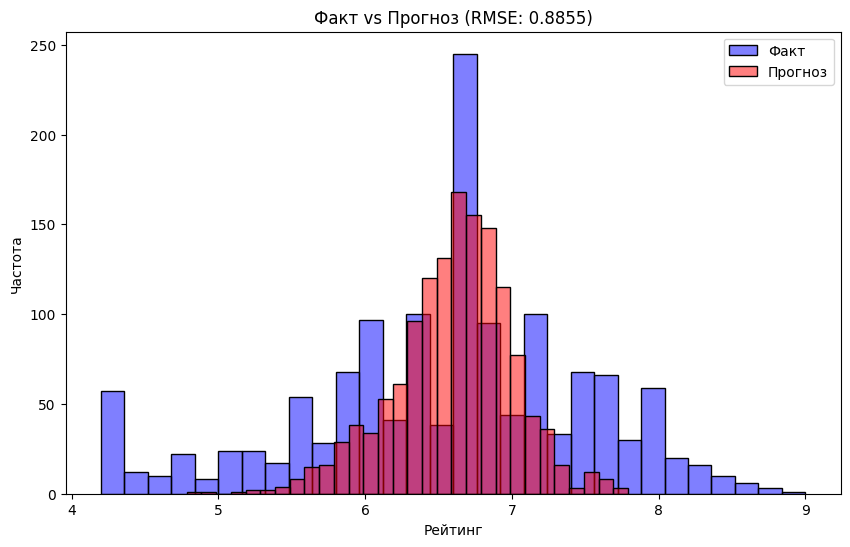

In [443]:
X_val_np = X_val.values if hasattr(X_val, 'values') else X_val

with torch.no_grad():
    y_pred = best_model(torch.FloatTensor(X_val_np)).numpy().flatten()

y_val_np = y_val.values if hasattr(y_val, 'values') else y_val

plot_comparison(y_val_np, y_pred)

#### 4) Выводы:

1. Лучшая комбинация параметров: 
- функция активации - leaky_relu
- значение dropout - 0.5
- наличие нормализации - да
- размер батча - 64
2. Наилучшее качество (RMSE): 0.8811

Гистограмма показывает, что модель чаще занижает оценки ближе к границам распределения и завышает в центре, а также придсказывает оценки в более узком диапазоне, нежели есть на самом деле (так же, как и baseline решение). 

Качество лучшей модели чуть улучшилось по сравнению с baseline решением: MSE_baseline = 0.7954 и MSE_best = 0.7795